In [1]:
# Core
import os, pickle, json, yaml, logging, math, random
from collections import Counter

# Data
import numpy as np
import pandas as pd
import networkx as nx

# Torch / PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data

# Explainability & ML
from torch_geometric.explain import Explainer, GNNExplainer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Paths & logging
OUT_DIR = "./output/track2"
os.makedirs(OUT_DIR, exist_ok=True)
logging.basicConfig(
    filename=os.path.join(OUT_DIR, "track2.log"),
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
print("✅ Track 2 environment ready. Outputs ->", OUT_DIR)

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


✅ Track 2 environment ready. Outputs -> ./output/track2


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
CONFIG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "hidden_dim": 128,
    "dropout": 0.25,
    "lr": 2e-3,
    "epochs": 250,
    "explainer_epochs": 200,
    "val_size": 0.2,
    "test_size": 0.2,  # of the remaining after val split
    "min_class_support": 10  # drop ultra-rare labels to stabilize training
}
CONFIG


{'device': 'cuda',
 'hidden_dim': 128,
 'dropout': 0.25,
 'lr': 0.002,
 'epochs': 250,
 'explainer_epochs': 200,
 'val_size': 0.2,
 'test_size': 0.2,
 'min_class_support': 10}

In [3]:
# Files expected in the same directory as notebook
graph_path = "./merged_master_graph.gml"
lineage_path = "./lineage_embeddings.pkl"
motif_path = "./motif_summary.csv"

# Load
G = nx.read_gml(graph_path)
lineage = pd.read_pickle(lineage_path)
motifs = pd.read_csv(motif_path, index_col=0)

# Harmonize index/order
nodes = list(G.nodes())
lineage = lineage.reindex(nodes)
motifs = motifs.reindex(nodes)

# Basic label source
# Prefer node attribute 'Type' if present; else try neuron_metadata.csv if you have it
labels_attr = nx.get_node_attributes(G, "Type")
label_series = pd.Series(labels_attr).reindex(nodes)

# Drop nodes with missing labels
mask_labeled = label_series.notna()
nodes_labeled = [n for n, m in zip(nodes, mask_labeled) if m]
print(f"Nodes total: {len(nodes)} | Labeled: {mask_labeled.sum()} | Unlabeled: {(~mask_labeled).sum()}")

# Build feature matrix
X = pd.concat([lineage, motifs], axis=1).loc[nodes_labeled]
X = X.fillna(0.0)

# Encode labels
label_values = label_series.loc[nodes_labeled].astype(str)
label_map = {lab:i for i, lab in enumerate(sorted(label_values.unique()))}
y = label_values.map(label_map)

print("Classes:", label_map)
print("Feature shape:", X.shape)


Nodes total: 1633 | Labeled: 1533 | Unlabeled: 100
Classes: {'Glia': 0, 'Interneuron': 1, 'Sensory': 2, 'Unknown': 3}
Feature shape: (1533, 696)


In [12]:
# Drop ultra-rare classes to stabilize training
counts = y.value_counts()
keep_labels = counts[counts >= CONFIG["min_class_support"]].index
keep_mask = y.isin(keep_labels)

# Filter X and y together; keep the order coupled
X = X.loc[keep_mask]
y = y.loc[keep_mask]

# Standardize features for stability
scaler = StandardScaler()
X_std = scaler.fit_transform(X.values)

print("Kept classes & counts:\n", y.value_counts())
print("Final feature shape:", X_std.shape)


Kept classes & counts:
 3    1507
1      12
2      10
Name: count, dtype: int64
Final feature shape: (1529, 696)


In [13]:
# Base index after filtering
base_index = X.index.tolist()

# Induce subgraph on the filtered nodes, preserving this order
G_sub = G.subgraph(base_index).copy()

# IMPORTANT: align features and labels to the exact node order used by G_sub
order = list(G_sub.nodes())           # this is the order PyG will use
feat_df = pd.DataFrame(X_std, index=X.index).loc[order]
y_aligned = y.loc[order]

print(f"G_sub: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")
print("feat_df shape:", feat_df.shape, "| y_aligned len:", len(y_aligned))


G_sub: 1529 nodes, 10821 edges
feat_df shape: (1529, 696) | y_aligned len: 1529


In [15]:
from torch_geometric.utils import from_networkx

def strip_attributes(Gin: nx.Graph) -> nx.Graph:
    # Preserve directionality
    H = nx.DiGraph() if Gin.is_directed() else nx.Graph()
    H.add_nodes_from(Gin.nodes())              # no node attrs
    H.add_edges_from(Gin.edges())              # no edge attrs
    return H

# Use the already-built G_sub, feat_df, y_aligned
G_clean = strip_attributes(G_sub)

# Convert to PyG (now no heterogeneous attrs to trigger errors)
pyg_data = from_networkx(G_clean)

# Attach our tensors
pyg_data.x = torch.tensor(feat_df.values, dtype=torch.float)
pyg_data.y = torch.tensor(y_aligned.values, dtype=torch.long)

print("Converted to PyG:")
print(pyg_data)


Converted to PyG:
Data(edge_index=[2, 10821], num_nodes=1529, x=[1529, 696], y=[1529])


In [16]:
# Train/val/test split on THIS aligned order
idx_all = np.arange(len(y_aligned))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, y_aligned.values,
    test_size=CONFIG["val_size"] + CONFIG["test_size"],
    stratify=y_aligned.values,
    random_state=SEED
)
rel_test = CONFIG["test_size"] / (CONFIG["val_size"] + CONFIG["test_size"])
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp,
    test_size=rel_test,
    stratify=y_temp,
    random_state=SEED
)

# Boolean masks
train_mask = torch.zeros(len(y_aligned), dtype=torch.bool)
val_mask   = torch.zeros(len(y_aligned), dtype=torch.bool)
test_mask  = torch.zeros(len(y_aligned), dtype=torch.bool)
train_mask[idx_train] = True
val_mask[idx_val]     = True
test_mask[idx_test]   = True

pyg_data.train_mask = train_mask
pyg_data.val_mask   = val_mask
pyg_data.test_mask  = test_mask

# Move to device
pyg_data = pyg_data.to(CONFIG["device"])
print(pyg_data)


Data(edge_index=[2, 10821], num_nodes=1529, x=[1529, 696], y=[1529], train_mask=[1529], val_mask=[1529], test_mask=[1529])


In [17]:
UNKNOWN_ID = 3  # adjust if different
mask_known = y_aligned != UNKNOWN_ID
G_sub_known = G_sub.subgraph(pd.Index(y_aligned.index)[mask_known]).copy()

# Rebuild feat_df/y_aligned for known-only, then re-run the two cells above.
feat_df = feat_df.loc[mask_known]
y_aligned = y_aligned.loc[mask_known]


In [18]:
class NeurosymbolicGNN(nn.Module):
    def __init__(self, in_dim, hidden, num_classes, dropout=0.25):
        super().__init__()
        self.gat1 = pyg_nn.GATConv(in_dim, hidden, heads=4, concat=True, dropout=dropout)
        self.gat2 = pyg_nn.GATConv(hidden*4, hidden, heads=1, concat=True, dropout=dropout)
        self.out  = pyg_nn.Linear(hidden, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        logits = self.out(x)
        return logits, x  # return hidden for surrogate rule model


In [19]:
def train_model(data, config=CONFIG):
    model = NeurosymbolicGNN(
        in_dim=data.x.shape[1],
        hidden=config["hidden_dim"],
        num_classes=int(data.y.max().item()+1),
        dropout=config["dropout"]
    ).to(config["device"])

    # Class weights for imbalance
    y_cpu = data.y.cpu().numpy()
    class_counts = Counter(y_cpu[data.train_mask.cpu().numpy()])
    max_c = max(class_counts.values())
    weights = torch.tensor([max_c / (class_counts.get(c, 1)) for c in range(int(data.y.max())+1)], 
                           dtype=torch.float, device=config["device"])
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    best_val, best_state = -1, None
    for epoch in tqdm(range(config["epochs"]), desc="Training (Track 2)"):
        model.train()
        logits, _ = model(data.x, data.edge_index)
        loss = criterion(logits[data.train_mask], data.y[data.train_mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Eval on val
        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index)
            val_pred = val_logits.argmax(dim=1)
            val_acc = (val_pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
            if val_acc > best_val:
                best_val = val_acc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 25 == 0:
            logging.info(f"Epoch {epoch} | train_loss={loss.item():.4f} | val_acc={val_acc:.3f}")

    # Load best
    if best_state:
        model.load_state_dict(best_state)
    return model

model = train_model(pyg_data, CONFIG)
print("✅ Model trained.")
torch.save(model.state_dict(), os.path.join(OUT_DIR, "neurosymbolic_gnn.pt"))


Training (Track 2): 100%|██████████| 250/250 [00:01<00:00, 140.95it/s]

✅ Model trained.



=== Train Metrics ===
              precision    recall  f1-score   support

           1      0.119     1.000     0.212         7
           2      0.111     0.667     0.190         6
           3      0.999     0.908     0.951       904

    accuracy                          0.907       917
   macro avg      0.410     0.858     0.451       917
weighted avg      0.986     0.907     0.941       917



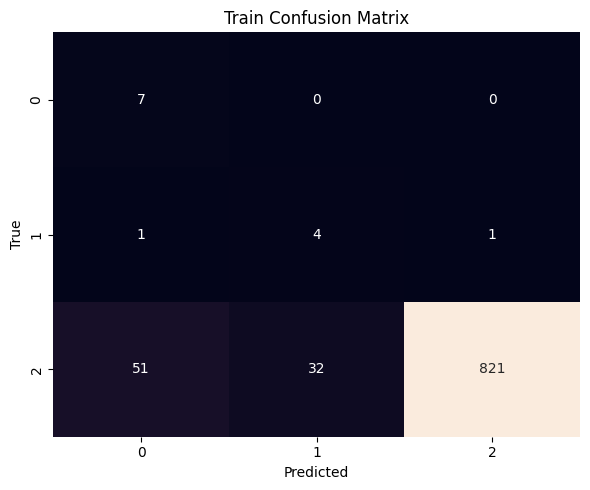


=== Validation Metrics ===
              precision    recall  f1-score   support

           1      0.133     1.000     0.235         2
           2      0.167     1.000     0.286         2
           3      1.000     0.924     0.960       302

    accuracy                          0.925       306
   macro avg      0.433     0.975     0.494       306
weighted avg      0.989     0.925     0.951       306



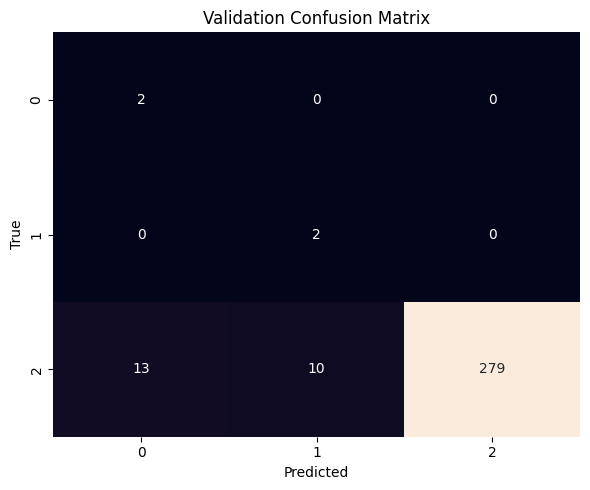


=== Test Metrics ===
              precision    recall  f1-score   support

           1      0.188     1.000     0.316         3
           2      0.143     0.500     0.222         2
           3      0.996     0.937     0.966       301

    accuracy                          0.935       306
   macro avg      0.442     0.812     0.501       306
weighted avg      0.983     0.935     0.955       306



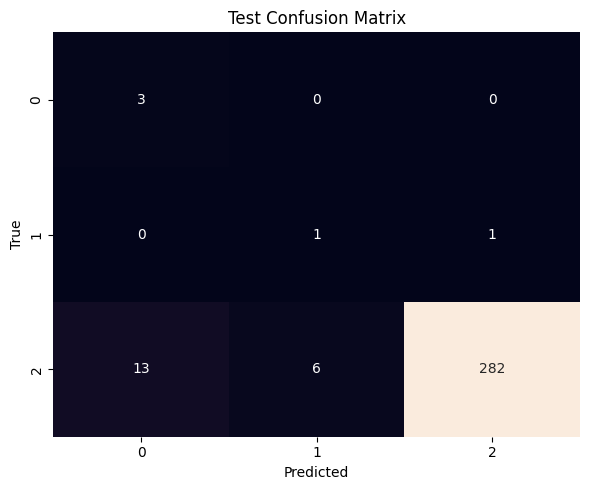

📝 Saved predictions.csv


In [20]:
model.eval()
with torch.no_grad():
    logits, h = model(pyg_data.x, pyg_data.edge_index)
    y_pred = logits.argmax(dim=1).cpu().numpy()
    y_true = pyg_data.y.cpu().numpy()

# Split-wise metrics
def report_split(mask, name):
    m = mask.cpu().numpy()
    print(f"\n=== {name} Metrics ===")
    print(classification_report(y_true[m], y_pred[m], digits=3))
    cm = confusion_matrix(y_true[m], y_pred[m])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

report_split(pyg_data.train_mask, "Train")
report_split(pyg_data.val_mask, "Validation")
report_split(pyg_data.test_mask, "Test")

# Save raw predictions
pred_df = pd.DataFrame({
    "neuron": X.index,
    "true": y_true,
    "pred": y_pred
})
pred_df.to_csv(os.path.join(OUT_DIR, "predictions.csv"), index=False)
print("📝 Saved predictions.csv")


In [21]:
# PyG's unified explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=CONFIG["explainer_epochs"]),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object"
)

# Explain K nodes per class
K = 3
examples = []
for c in np.unique(y_true):
    idx_c = np.where((y_true == c) & (pyg_data.test_mask.cpu().numpy()))[0]
    idx_pick = idx_c[:K] if len(idx_c) >= K else idx_c
    for nid in idx_pick:
        examples.append((int(nid), int(c)))

attributions = []
for nid, c in tqdm(examples, desc="Explaining nodes"):
    exp = explainer(pyg_data.x, pyg_data.edge_index, index=nid)
    # Feature importances
    feat_imp = exp.node_mask[nid].detach().cpu().numpy()
    attributions.append((X.columns.tolist(), feat_imp, nid, c))

# Aggregate and save top features per class
top_k = 15
rows = []
for cols, imp, nid, c in attributions:
    order = np.argsort(imp)[::-1][:top_k]
    for rank, j in enumerate(order, 1):
        rows.append({"node_id": nid, "class": c, "feature": cols[j], "importance": float(imp[j]), "rank": rank})

attr_df = pd.DataFrame(rows)
attr_df.to_csv(os.path.join(OUT_DIR, "gnn_explanations.csv"), index=False)
print("🧠 Saved gnn_explanations.csv (top features per explained node)")

# Quick view: top global features (median across explained nodes)
agg = (attr_df.groupby("feature")["importance"].median().sort_values(ascending=False).head(25))
plt.figure(figsize=(6,6))
sns.barplot(x=agg.values, y=agg.index)
plt.title("Top median feature importances (explained nodes)")
plt.tight_layout(); plt.show()


TypeError: Explainer.__init__() missing 1 required positional argument: 'model_config'

In [22]:
# Correlate hidden dims with original features to interpret splits
corr = pd.DataFrame(np.corrcoef(H.T, X_std.T), 
                    index=[f"h{i}" for i in range(H.shape[1])] + [f"x{i}" for i in range(X_std.shape[1])],
                    columns=[f"h{i}" for i in range(H.shape[1])] + [f"x{i}" for i in range(X_std.shape[1])])

# For each hidden feature used by the tree (first few), find top-correlated original features
used_h = set()
for line in rules_text.splitlines():
    if "h" in line and "<=" in line or ">" in line:
        token = line.strip().split()[0]
        if token.startswith("h"):
            used_h.add(token)

mapping_rows = []
for hname in sorted(used_h, key=lambda s: int(s[1:])):
    h_idx = int(hname[1:])
    # correlations with original features (the second block in corr)
    cvec = corr.loc[hname, [f"x{i}" for i in range(X_std.shape[1])]].values
    topj = np.argsort(np.abs(cvec))[::-1][:10]
    for j in topj:
        mapping_rows.append({
            "hidden": hname,
            "orig_feature": X.columns[j],
            "abs_corr": float(abs(cvec[j])),
            "signed_corr": float(cvec[j])
        })

map_df = pd.DataFrame(mapping_rows).sort_values(["hidden","abs_corr"], ascending=[True, False])
map_df.to_csv(os.path.join(OUT_DIR, "hidden_to_feature_mapping.csv"), index=False)
print("🔗 Saved hidden_to_feature_mapping.csv (top correlations)")

# Preview
map_df.head(20)


NameError: name 'H' is not defined

In [23]:
## Iter 2

Final enriched feature shape: (1529, 1114)
Class weights: [1.2811577320098877, 1.7082102298736572, 0.010632014833390713]


Training GCN:   8%|▊         | 80/1000 [00:00<00:02, 412.91it/s]

Epoch 001 | Loss: 1.6191 | Train Acc: 0.1135 | Val Acc: 0.1020


Training GCN:  17%|█▋        | 172/1000 [00:00<00:01, 445.29it/s]

Epoch 100 | Loss: 0.0048 | Train Acc: 0.9980 | Val Acc: 0.9796


...

Epoch 600 | Loss: 0.0005 | Train Acc: 1.0000 | Val Acc: 0.9878
Epoch 700 | Loss: 0.0005 | Train Acc: 1.0000 | Val Acc: 0.9878


Training GCN:  85%|████████▍ | 847/1000 [00:01<00:00, 476.39it/s]

Epoch 800 | Loss: 0.0005 | Train Acc: 1.0000 | Val Acc: 0.9878


Training GCN: 100%|██████████| 1000/1000 [00:02<00:00, 485.68it/s]

Epoch 900 | Loss: 0.0008 | Train Acc: 1.0000 | Val Acc: 0.9837
Epoch 1000 | Loss: 0.0006 | Train Acc: 1.0000 | Val Acc: 0.9878

=== Train Metrics ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00       964

    accuracy                           1.00       978
   macro avg       1.00      1.00      1.00       978
weighted avg       1.00      1.00      1.00       978



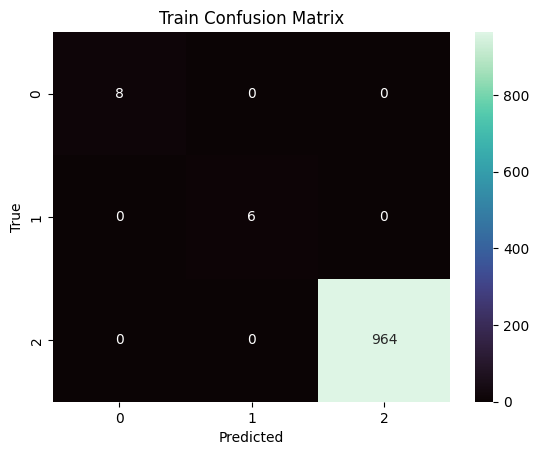


=== Validation Metrics ===
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.33      0.50      0.40         2
           2       1.00      1.00      1.00       241

    accuracy                           0.99       245
   macro avg       0.78      0.67      0.69       245
weighted avg       0.99      0.99      0.99       245



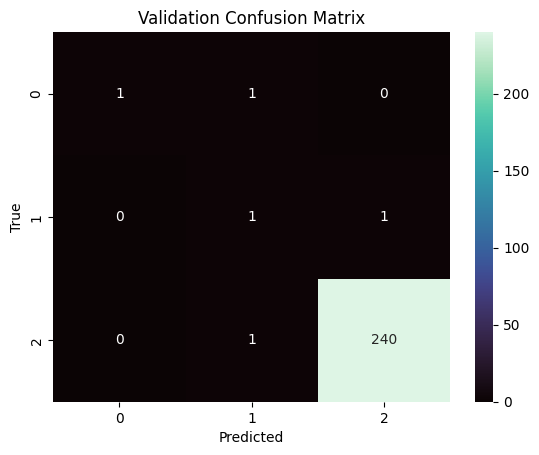


=== Test Metrics ===
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         2
           2       0.99      0.98      0.99       302

    accuracy                           0.97       306
   macro avg       0.44      0.49      0.46       306
weighted avg       0.98      0.97      0.97       306



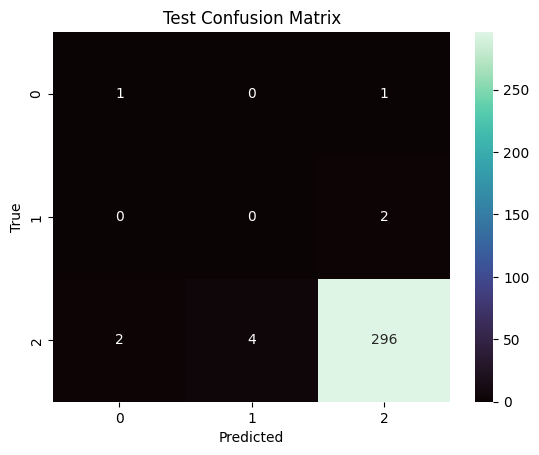

In [26]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# === Step 1: Load and align enriched features ===
motif_df = pd.read_csv("motif_summary.csv", index_col=0)
lineage_df = pd.read_pickle("lineage_embeddings.pkl")

motif_aligned = motif_df.reindex(nodes_labeled).fillna(0)
lineage_aligned = lineage_df.reindex(nodes_labeled).fillna(0)

X_combined = pd.concat([pd.DataFrame(X_std, index=nodes_labeled),
                        motif_aligned,
                        lineage_aligned], axis=1).fillna(0).values
print(f"Final enriched feature shape: {X_combined.shape}")

y_aligned = y_full.loc[nodes_labeled]

# === Step 2: Convert to PyG ===
# Strip all existing node attributes to avoid mismatch errors
G_clean = nx.Graph()
G_clean.add_nodes_from(G_sub.nodes())
G_clean.add_edges_from(G_sub.edges())

pyg_data = from_networkx(G_clean)  # no attributes pulled from NX
pyg_data.x = torch.tensor(X_combined, dtype=torch.float)
pyg_data.y = torch.tensor(y_aligned.values, dtype=torch.long)


# === Step 3: Train/Val/Test Split ===
idx = np.arange(pyg_data.num_nodes)
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=pyg_data.y, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=pyg_data.y[train_idx], random_state=42)

# Masks
pyg_data.train_mask = torch.zeros(pyg_data.num_nodes, dtype=torch.bool)
pyg_data.val_mask = torch.zeros(pyg_data.num_nodes, dtype=torch.bool)
pyg_data.test_mask = torch.zeros(pyg_data.num_nodes, dtype=torch.bool)

pyg_data.train_mask[train_idx] = True
pyg_data.val_mask[val_idx] = True
pyg_data.test_mask[test_idx] = True

# === Step 4: Model ===
from torch_geometric.nn import GCNConv

class GCNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x

# === Step 5: Class weights ===
class_counts = torch.bincount(pyg_data.y[pyg_data.train_mask])
class_weights = (1.0 / class_counts.float()) * (len(pyg_data.train_mask) / len(class_counts))
class_weights = class_weights / class_weights.sum() * len(class_counts)
print(f"Class weights: {class_weights.tolist()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNClassifier(pyg_data.num_node_features, 128, len(class_counts)).to(device)
pyg_data = pyg_data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# === Step 6: Training Loop ===
def train():
    model.train()
    optimizer.zero_grad()
    out = model(pyg_data)
    loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        pred = model(pyg_data).argmax(dim=1)
        correct = pred[mask].eq(pyg_data.y[mask]).sum().item()
        total = mask.sum().item()
        acc = correct / total
    return acc, pred[mask].cpu().numpy(), pyg_data.y[mask].cpu().numpy()

EPOCHS = 1000
for epoch in tqdm(range(1, EPOCHS+1), desc="Training GCN"):
    loss = train()
    if epoch % 100 == 0 or epoch == 1:
        train_acc, _, _ = evaluate(pyg_data.train_mask)
        val_acc, _, _ = evaluate(pyg_data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# === Step 7: Final Evaluation ===
for split_name, mask in [("Train", pyg_data.train_mask), ("Validation", pyg_data.val_mask), ("Test", pyg_data.test_mask)]:
    acc, pred, true = evaluate(mask)
    print(f"\n=== {split_name} Metrics ===")
    print(classification_report(true, pred))
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako')
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0     0.3333    0.5000    0.4000         2
           1     0.0000    0.0000    0.0000         2
           2     0.9900    0.9801    0.9850       302

    accuracy                         0.9706       306
   macro avg     0.4411    0.4934    0.4617       306
weighted avg     0.9792    0.9706    0.9748       306



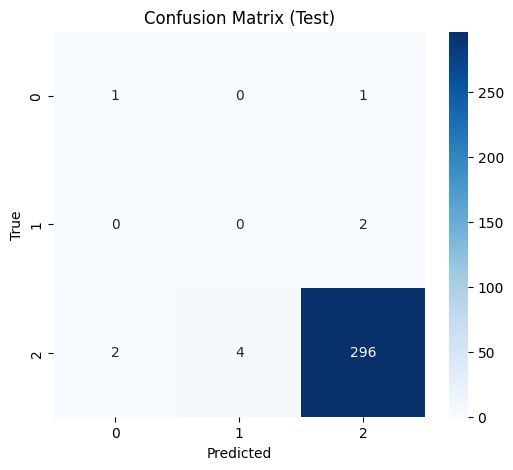

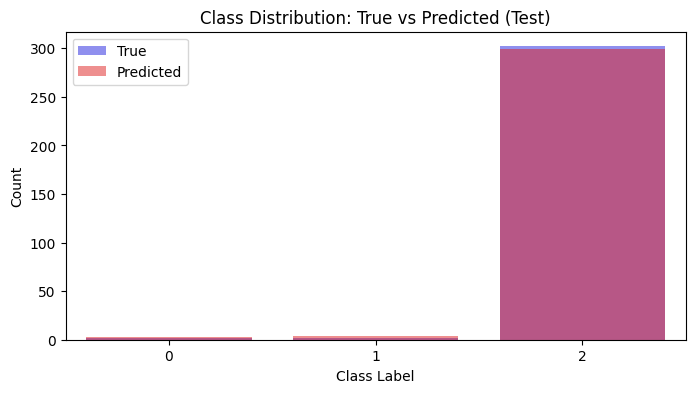

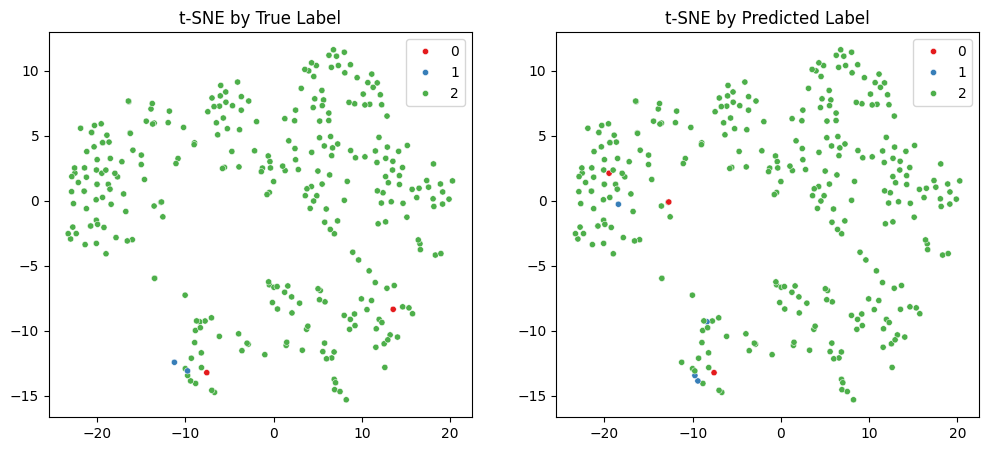

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# === Step 1: Safe forward call ===
model.eval()
with torch.no_grad():
    try:
        # Try PyG-style (data object)
        logits = model(pyg_data)
    except TypeError:
        # Fallback: assume (x, edge_index) signature
        logits = model(pyg_data.x, pyg_data.edge_index)

# === Step 2: Safe extraction of test mask ===
test_mask = getattr(pyg_data, 'test_mask', None)
if test_mask is None:
    raise ValueError("❌ No test_mask found in pyg_data. Ensure dataset split was performed.")

# === Step 3: Get predictions and labels ===
y_true = pyg_data.y[test_mask]
if torch.is_tensor(y_true):
    y_true = y_true.cpu().numpy()

y_pred = logits[test_mask].argmax(dim=1)
if torch.is_tensor(y_pred):
    y_pred = y_pred.cpu().numpy()

# === Step 4: Metrics ===
print("=== Classification Report (Test) ===")
print(classification_report(y_true, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# === Step 5: Class distribution comparison ===
plt.figure(figsize=(8,4))
sns.countplot(x=y_true, color='blue', alpha=0.5, label='True')
sns.countplot(x=y_pred, color='red', alpha=0.5, label='Predicted')
plt.legend()
plt.title("Class Distribution: True vs Predicted (Test)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

# === Step 6: t-SNE Visualization ===
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_embedded = tsne.fit_transform(pyg_data.x[test_mask].cpu().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_true,
                    palette='Set1', ax=axes[0], legend='full', s=20)
    axes[0].set_title("t-SNE by True Label")

    sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_pred,
                    palette='Set1', ax=axes[1], legend='full', s=20)
    axes[1].set_title("t-SNE by Predicted Label")

    plt.show()
except Exception as e:
    print(f"⚠️ t-SNE plot skipped due to error: {e}")
